In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [93]:
df  = pd.read_csv("loan_approval_data.csv")

In [94]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Handle missing data

In [95]:
categorical_cols = df.select_dtypes(include=["str"]).columns
numerical_cols = df.select_dtypes(include=["float64" , "int64"]).columns



from sklearn.impute import SimpleImputer

numerical_imputer = SimpleImputer(strategy="mean")
df[numerical_cols]=numerical_imputer.fit_transform(df[numerical_cols])

categorical_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   str    
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   str    
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   str    
 15  Property_Area       1000 non-null   str    
 16  Education_Level   

EDA - Exploratory data analysis

Text(0.5, 1.0, 'Is Loan approved or not?')

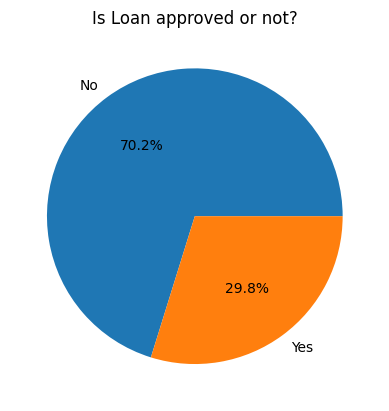

In [96]:
#how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No" , "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

<Axes: title={'center': 'co - applicant Income Distribution'}, xlabel='Coapplicant_Income', ylabel='Count'>

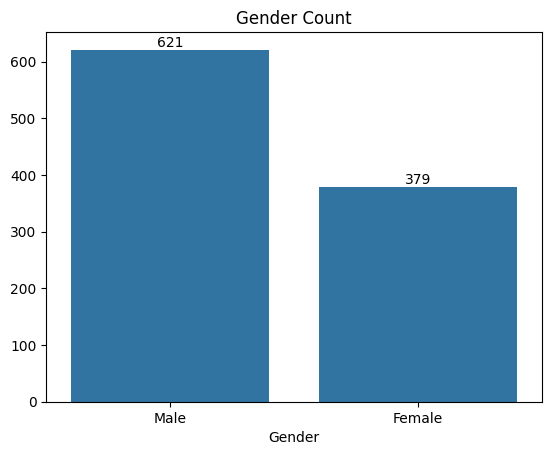

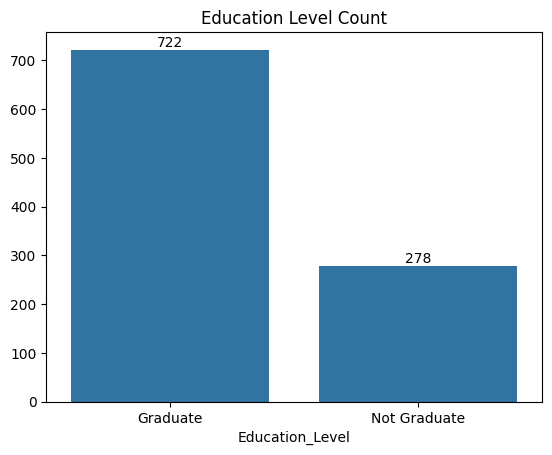

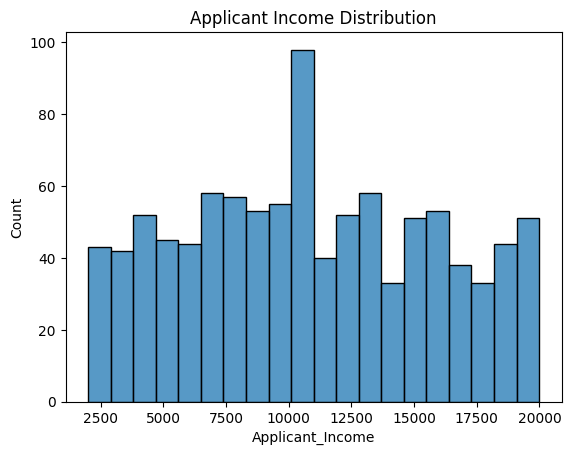

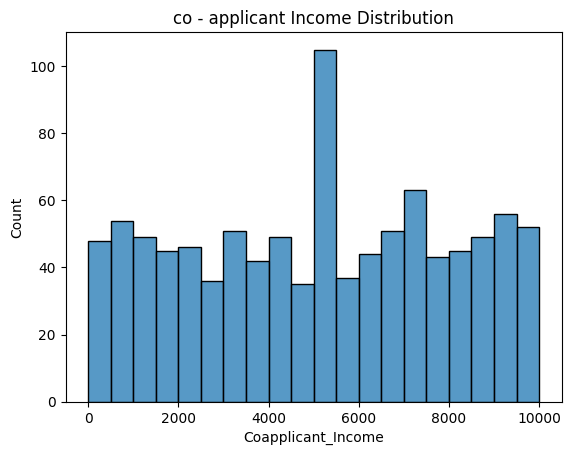

In [97]:
#analyze categories

plt.figure()
gender_cnt = df["Gender"].value_counts()
ax1 = sns.barplot(
    x=gender_cnt.index,
    y=gender_cnt.values
)
ax1.bar_label(ax1.containers[0])
plt.title("Gender Count")


plt.figure()
edu_cnt = df["Education_Level"].value_counts()
ax2 = sns.barplot(
    x=edu_cnt.index,
    y=edu_cnt.values
)
ax2.bar_label(ax2.containers[0])
plt.title("Education Level Count")


#analyze income
plt.figure()
plt.title("Applicant Income Distribution")
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)


plt.figure()
plt.title("co - applicant Income Distribution")
sns.histplot(
    data=df,
    x = "Coapplicant_Income",
    bins=20
)




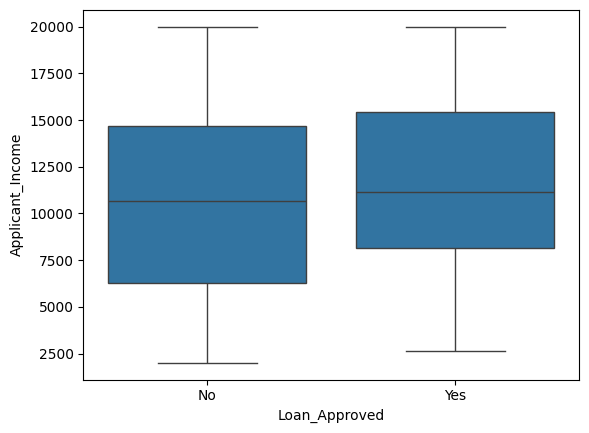

<Figure size 640x480 with 0 Axes>

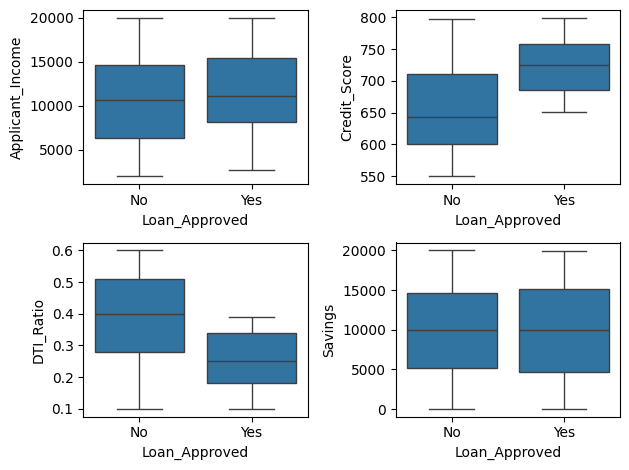

In [98]:
# outliers - box plots
plt.figure()
sns.boxplot(
    data= df,
    x = "Loan_Approved", 
    y = "Applicant_Income"
)


plt.figure()
fig,axes  = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()



<Axes: xlabel='Applicant_Income', ylabel='Count'>

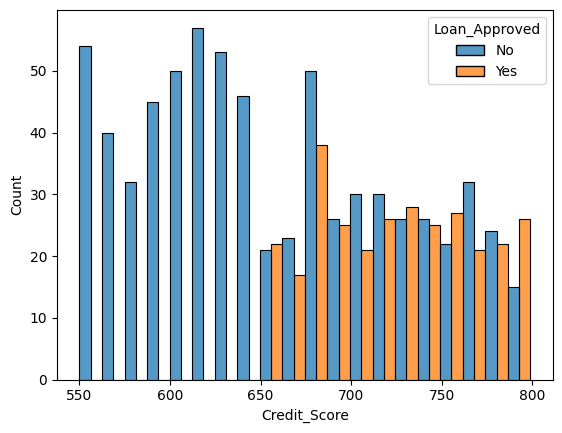

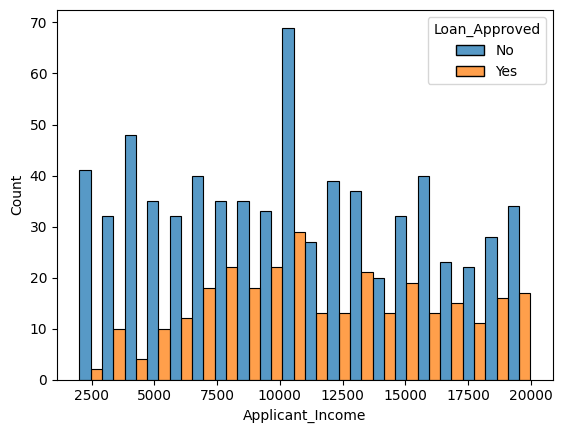

In [99]:
#credit score with load approved

sns.histplot(
    data=df,
    x ="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20,
)
plt.figure()
sns.histplot(
    data=df,
    x ="Applicant_Income",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20,
)

In [100]:
#remove APPLICANT ID

df =  df.drop("Applicant_ID" , axis=1, errors="ignore")




Feature Encoding

In [110]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

#label encoder
le = LabelEncoder()

df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

df.head()









#one hot encoder
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area" , "Gender" , "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns= cols),encoded_df] , axis=1)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

corelation heatmap